In [51]:
%config InlineBackend.figure_formats = ['jpeg']

import sys
sys.path.insert(0, "../src")

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import SimpleITK as sitk
from tqdm.auto import tqdm

from generate_cases import *
from seg_metrics import compute_segmentation_metrics

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.figsize": (6.5, 4.5),   # letter-paper single column width
    "figure.dpi": 72,
    "axes.prop_cycle": plt.cycler(color=["black", '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']),
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## Part 1: Segmentation methods vs. ground truth (label_wg), full ProstateX cohort

In [52]:
# Collect all the data metadata
csv_path = Path("../data/raw/github/prostatex_masks/index.csv")
prostatex_cases = pd.read_csv(csv_path)
assert not prostatex_cases["ID"].duplicated().any(), "Duplicate ProstateX IDs in index.csv!"

# Convert all mask/image paths to absolute paths
for col in ["t2", "label_wg", "label_tz", "label_pz"]:
    prostatex_cases[col] = prostatex_cases[col].apply(lambda x: str((csv_path.parent / x).resolve()))

# Concatenate locally run predictions

# monai bundle output mirrors the source layout: Files/prostate/Images/<t2 stem>/<t2 stem>_trans.nii.gz
prostatex_cases["Prostate158_adams22"] = prostatex_cases["t2"].apply(
    lambda p: f"../results/prostatex_pred_monai_prostate/Files/prostate/Images/{Path(p).name.removesuffix('.nii.gz')}/{Path(p).name.removesuffix('.nii.gz')}_trans.nii.gz"
)
assert all(Path(p).exists() for p in prostatex_cases["Prostate158_adams22"]), "Some predictions are missing!"

prostatex_cases["Prostate158_nnunet"] = prostatex_cases["ID"].apply(lambda id: f"../results/prostatex_pred_prostate158_3d_fullres/{id}.nii.gz")
assert all(Path(p).exists() for p in prostatex_cases["Prostate158_nnunet"]), "Some predictions are missing!"

prostatex_cases["pooled_nnunet"] = prostatex_cases["ID"].apply(lambda id: f"../results/prostatex_pred_pooled2_3d_fullres/{id}.nii.gz")
assert all(Path(p).exists() for p in prostatex_cases["pooled_nnunet"]), "Some predictions are missing!"

prostatex_cases


,ID,t2,label_wg,label_tz,label_pz,Prostate158_adams22,Prostate158_nnunet,pooled_nnunet
0,ProstateX-0000,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,../results/prostatex_pred_monai_prostate/Files...,../results/prostatex_pred_prostate158_3d_fullr...,../results/prostatex_pred_pooled2_3d_fullres/P...
1,ProstateX-0001,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,../results/prostatex_pred_monai_prostate/Files...,../results/prostatex_pred_prostate158_3d_fullr...,../results/prostatex_pred_pooled2_3d_fullres/P...
2,ProstateX-0002,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,../results/prostatex_pred_monai_prostate/Files...,../results/prostatex_pred_prostate158_3d_fullr...,../results/prostatex_pred_pooled2_3d_fullres/P...
3,ProstateX-0003,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,../results/prostatex_pred_monai_prostate/Files...,../results/prostatex_pred_prostate158_3d_fullr...,../results/prostatex_pred_pooled2_3d_fullres/P...
4,ProstateX-0004,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,../results/prostatex_pred_monai_prostate/Files...,../results/prostatex_pred_prostate158_3d_fullr...,../results/prostatex_pred_pooled2_3d_fullres/P...
...,...,...,...,...,...,...,...,...
199,ProstateX-0199,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,../results/prostatex_pred_monai_prostate/Files...,../results/prostatex_pred_prostate158_3d_fullr...,../results/prostatex_pred_pooled2_3d_fullres/P...
200,ProstateX-0200,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,../results/prostatex_pred_monai_prostate/Files...,../results/prostatex_pred_prostate158_3d_fullr...,../results/prostatex_pred_pooled2_3d_fullres/P...
201,ProstateX-0201,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,../results/prostatex_pred_monai_prostate/Files...,../results/prostatex_pred_prostate158_3d_fullr...,../results/prostatex_pred_pooled2_3d_fullres/P...
202,ProstateX-0202,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,/home/bshi/Documents/prostate_train/data/raw/g...,../results/prostatex_pred_monai_prostate/Files...,../results/prostatex_pred_prostate158_3d_fullr...,../results/prostatex_pred_pooled2_3d_fullres/P...


In [53]:
from concurrent.futures import ProcessPoolExecutor
import os

def _row_volumes(row):
    import nibabel as nib
    import numpy as np
    for col, path in row.items():
        if col in ("ID", "t2", "label_tz", "label_pz"):
            continue
        img = nib.load(path)
        data = np.asarray(img.dataobj)
        voxel_vol_mm3 = np.prod(img.header.get_zooms()[:3])
        row[col] = (data > 0).sum() * voxel_vol_mm3 / 1000.0
    return row

rows = prostatex_cases.to_dict("records")

with ProcessPoolExecutor(os.cpu_count() - 1) as pool:
    results = list(tqdm(pool.map(_row_volumes, rows), total=len(rows)))

volumes = pd.DataFrame(results)
volumes = volumes.drop(columns=["label_tz", "label_pz"])
volumes["gt"] = volumes["label_wg"]

volumes


  0%|          | 0/204 [00:00<?, ?it/s]

,ID,t2,label_wg,Prostate158_adams22,Prostate158_nnunet,pooled_nnunet,gt
0,ProstateX-0000,/home/bshi/Documents/prostate_train/data/raw/g...,45.158250,47.963250,40.287750,42.684000,45.158250
1,ProstateX-0001,/home/bshi/Documents/prostate_train/data/raw/g...,33.600750,27.968996,25.479000,27.327750,33.600750
2,ProstateX-0002,/home/bshi/Documents/prostate_train/data/raw/g...,28.818000,33.164226,30.252750,32.487000,28.818000
3,ProstateX-0003,/home/bshi/Documents/prostate_train/data/raw/g...,136.920000,133.458074,126.985500,128.099250,136.920000
4,ProstateX-0004,/home/bshi/Documents/prostate_train/data/raw/g...,160.324875,152.384673,136.081125,144.702000,160.324875
...,...,...,...,...,...,...,...
199,ProstateX-0199,/home/bshi/Documents/prostate_train/data/raw/g...,53.094551,61.028144,55.801723,56.558250,53.094551
200,ProstateX-0200,/home/bshi/Documents/prostate_train/data/raw/g...,32.935043,41.207526,30.091184,35.513121,32.935043
201,ProstateX-0201,/home/bshi/Documents/prostate_train/data/raw/g...,53.624215,57.278743,53.572957,58.154836,53.624215
202,ProstateX-0202,/home/bshi/Documents/prostate_train/data/raw/g...,46.780348,50.693027,43.686844,44.908488,46.780348


In [54]:
from concurrent.futures import ProcessPoolExecutor
import os
from itertools import combinations

SEG_COLS = [
    "label_wg",
    "Prostate158_adams22",
    "Prostate158_nnunet",
    "pooled_nnunet",
]

def _pairwise_dsc_case(row):
    import SimpleITK as sitk
    import numpy as np

    ref_img = sitk.ReadImage(str(row[SEG_COLS[0]]), sitk.sitkUInt8)
    masks = {SEG_COLS[0]: sitk.GetArrayFromImage(ref_img).ravel() > 0}
    for col in SEG_COLS[1:]:
        img = sitk.ReadImage(str(row[col]), sitk.sitkUInt8)
        needs_resample = (
            img.GetSize() != ref_img.GetSize()
            or not np.allclose(img.GetSpacing(), ref_img.GetSpacing(), rtol=1e-4)
            or not np.allclose(img.GetOrigin(), ref_img.GetOrigin(), rtol=1e-4)
        )
        if needs_resample:
            img = sitk.Resample(img, ref_img, sitk.Transform(),
                                sitk.sitkNearestNeighbor, 0, sitk.sitkUInt8)
        masks[col] = sitk.GetArrayFromImage(img).ravel() > 0

    results = {"ID": row["ID"]}
    for m1, m2 in combinations(SEG_COLS, 2):
        a, b = masks[m1], masks[m2]
        denom = int(a.sum()) + int(b.sum())
        results[f"{m1}||{m2}"] = (
            2 * int((a & b).sum()) / denom if denom > 0 else float("nan")
        )
    return results

rows = prostatex_cases.to_dict("records")
with ProcessPoolExecutor(max_workers=os.cpu_count() - 1) as pool:
    dsc_records = list(tqdm(pool.map(_pairwise_dsc_case, rows), total=len(rows)))

dsc_df = pd.DataFrame(dsc_records)

dsc_matrix = pd.DataFrame(np.ones((len(SEG_COLS), len(SEG_COLS))),
                           index=SEG_COLS, columns=SEG_COLS)
for m1, m2 in combinations(SEG_COLS, 2):
    val = dsc_df[f"{m1}||{m2}"].mean()
    dsc_matrix.loc[m1, m2] = val
    dsc_matrix.loc[m2, m1] = val

print(f"Mean pairwise DSC across {len(prostatex_cases)} cases\n")
dsc_matrix.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1).format(precision=3)


  0%|          | 0/204 [00:00<?, ?it/s]

Mean pairwise DSC across 204 cases



,label_wg,Prostate158_adams22,Prostate158_nnunet,pooled_nnunet
label_wg,1.000,0.882,0.889,0.907
Prostate158_adams22,0.882,1.000,0.918,0.922
Prostate158_nnunet,0.889,0.918,1.000,0.947
pooled_nnunet,0.907,0.922,0.947,1.000


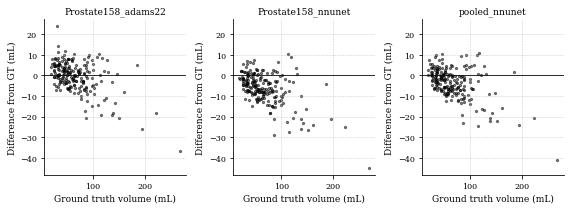

In [55]:
methods = [
    "Prostate158_adams22",
    "Prostate158_nnunet",
    "pooled_nnunet",
]

ncols = 3
nrows = -(-len(methods) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(8, 3), sharex=True, sharey=True)
axes = axes.flatten()

for ax, method in zip(axes, methods):
    diff = volumes[method] - volumes["gt"]
    ax.scatter(volumes["gt"], diff, s=5, alpha=0.5)
    ax.axhline(0, color="k", linewidth=0.8)
    ax.set_title(method, fontsize=9)
    ax.set_xlabel("Ground truth volume (mL)")
    ax.set_ylabel("Difference from GT (mL)")

for ax in fig.axes:
    ax.tick_params(labelleft=True, labelbottom=True)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

for ax in axes[len(methods):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


In [56]:
rows = {}
for method in methods:
    diff = volumes[method] - volumes["gt"]
    m, s = diff.mean(), diff.std()
    desc = diff.describe()
    rows[method] = {
        "mean": m,
        "95% LoA": f"[{m - 1.96*s:.1f}, {m + 1.96*s:.1f}]",
        "min": desc["min"], "25%": desc["25%"], "50%": desc["50%"],
        "75%": desc["75%"], "max": desc["max"], "N": int(desc["count"])
    }

df = pd.DataFrame(rows).T

numeric_cols = ["mean", "min", "25%", "50%", "75%", "max"]
df[numeric_cols] = df[numeric_cols].astype(float)

fmt = {c: "{:.1f}" for c in numeric_cols}
fmt["N"] = "{:.0f}"

df.style.format(fmt)

,mean,95% LoA,min,25%,50%,75%,max,N
Prostate158_adams22,-0.5,"[-15.2, 14.2]",-36.9,-4.2,0.4,4.5,23.8,204
Prostate158_nnunet,-6.3,"[-21.2, 8.7]",-44.9,-9.6,-5.6,-1.5,10.4,204
pooled_nnunet,-3.7,"[-18.1, 10.8]",-41.1,-7.3,-2.7,0.7,11.0,204


In [57]:
import pingouin as pg
from itertools import combinations

icc_methods = ["gt"] + methods
n = len(icc_methods)
icc_vals = pd.DataFrame(np.ones((n, n)), index=icc_methods, columns=icc_methods)

for m1, m2 in combinations(icc_methods, 2):
    long = pd.concat([
        volumes[["ID", m1]].rename(columns={m1: "volume"}).assign(rater=m1),
        volumes[["ID", m2]].rename(columns={m2: "volume"}).assign(rater=m2),
    ]).dropna(subset=["volume"])

    res = pg.intraclass_corr(data=long, targets="ID", raters="rater", ratings="volume", nan_policy='omit')
    row = res.set_index("Type").loc["ICC(A,1)"]   # two-way mixed, absolute agreement
    icc = row["ICC"]

    icc_vals.loc[m1, m2] = icc
    icc_vals.loc[m2, m1] = icc

print("ICC(A,1) — two-way mixed, absolute agreement (volume, mL)\n")
icc_vals.style.background_gradient(cmap="RdYlGn", vmin=0.8, vmax=1).format(precision=3)


ICC(A,1) — two-way mixed, absolute agreement (volume, mL)



,gt,Prostate158_adams22,Prostate158_nnunet,pooled_nnunet
gt,1.000,0.977,0.961,0.973
Prostate158_adams22,0.977,1.000,0.980,0.991
Prostate158_nnunet,0.961,0.980,1.000,0.994
pooled_nnunet,0.973,0.991,0.994,1.000


## Part 2: Merge PICAI clinical metadata via ProstateX-mapping.json

Some ProstateX cases have a PICAI clinical-data counterpart (patient_id/study_id, with prostate_volume, PSA, etc.),
linked via `ProstateX-mapping.json`. The mapping key embeds a scan date the ProstateX `index.csv` ID does not carry,
so some ProstateX IDs map to more than one PICAI target (e.g. `ProstateX-0025` has two mapping entries under
different dates). We treat those as ambiguous and drop them rather than guessing which scan date is correct.
Cases without any PICAI counterpart are kept with blank (NaN) clinical columns.

In [58]:
import json

mapping = json.load(open("../data/raw/zenodo/picai/picai_labels/additional_resources/ProstateX-mapping.json"))

# key format "ProstateX-XXXX_MM-DD-YYYY" -> "patient_id_study_id"; strip date to get the ProstateX ID
map_df = pd.DataFrame(
    [(k.split("_")[0], v) for k, v in mapping.items()],
    columns=["ID", "picai_key"],
)

# Explicit duplicate check + report
dupes = map_df[map_df["ID"].duplicated(keep=False)]
print(f"{dupes['ID'].nunique()} ProstateX IDs have ambiguous PICAI mappings — dropping (left blank):")
display(dupes.sort_values("ID"))
map_df = map_df[~map_df["ID"].isin(dupes["ID"])]

map_df[["patient_id", "study_id"]] = map_df["picai_key"].str.split("_", expand=True).astype(int)

marksheet = pd.read_csv("../data/raw/zenodo/picai/picai_labels/clinical_information/marksheet.csv")

volumes = volumes.merge(map_df[["ID", "patient_id", "study_id"]], on="ID", how="left")
volumes = volumes.merge(marksheet, on=["patient_id", "study_id"], how="left")

assert not volumes["ID"].duplicated().any(), "Merge produced duplicate ProstateX IDs!"
volumes


1 ProstateX IDs have ambiguous PICAI mappings — dropping (left blank):


,ID,picai_key
24,ProstateX-0025,11087_1001109
25,ProstateX-0025,11087_1001110


,ID,t2,label_wg,Prostate158_adams22,Prostate158_nnunet,pooled_nnunet,gt,patient_id,study_id,mri_date,patient_age,psa,psad,prostate_volume,histopath_type,lesion_GS,lesion_ISUP,case_ISUP,case_csPCa,center
0,ProstateX-0000,/home/bshi/Documents/prostate_train/data/raw/g...,45.158250,47.963250,40.287750,42.684000,45.158250,11373.0,1001396.0,2012-01-04,63.0,13.00,0.25,52.0,MRBx,4+3,3,3.0,YES,RUMC
1,ProstateX-0001,/home/bshi/Documents/prostate_train/data/raw/g...,33.600750,27.968996,25.479000,27.327750,33.600750,10795.0,1000811.0,2011-12-07,67.0,5.10,0.18,28.0,MRBx,"3+3,0+0","1,0",1.0,NO,RUMC
2,ProstateX-0002,/home/bshi/Documents/prostate_train/data/raw/g...,28.818000,33.164226,30.252750,32.487000,28.818000,11149.0,1001172.0,2011-12-24,61.0,6.10,0.16,39.0,MRBx,"3+4,3+3","2,1",2.0,YES,RUMC
3,ProstateX-0003,/home/bshi/Documents/prostate_train/data/raw/g...,136.920000,133.458074,126.985500,128.099250,136.920000,10310.0,1000316.0,2012-05-12,70.0,10.40,0.08,122.0,NaN,NaN,NaN,0.0,NO,RUMC
4,ProstateX-0004,/home/bshi/Documents/prostate_train/data/raw/g...,160.324875,152.384673,136.081125,144.702000,160.324875,10787.0,1000803.0,2012-03-26,68.0,28.30,0.19,146.0,MRBx,2+4,1,1.0,NO,RUMC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,ProstateX-0199,/home/bshi/Documents/prostate_train/data/raw/g...,53.094551,61.028144,55.801723,56.558250,53.094551,10570.0,1000582.0,2012-01-10,64.0,38.00,0.54,71.0,MRBx,"4+4,3+2","4,1",4.0,YES,RUMC
200,ProstateX-0200,/home/bshi/Documents/prostate_train/data/raw/g...,32.935043,41.207526,30.091184,35.513121,32.935043,10211.0,1000215.0,2012-02-13,63.0,17.90,0.52,34.0,MRBx,4+5,5,5.0,YES,RUMC
201,ProstateX-0201,/home/bshi/Documents/prostate_train/data/raw/g...,53.624215,57.278743,53.572957,58.154836,53.624215,10059.0,1000059.0,2012-02-21,69.0,52.00,0.85,61.0,MRBx,3+4,2,2.0,YES,RUMC
202,ProstateX-0202,/home/bshi/Documents/prostate_train/data/raw/g...,46.780348,50.693027,43.686844,44.908488,46.780348,11375.0,1001398.0,2012-02-18,65.0,NaN,NaN,84.0,MRBx,"5+3,N/A",4,4.0,YES,RUMC


In [59]:
clinical = volumes.dropna(subset=["psa", "prostate_volume"]).copy()
print(f"{len(clinical)} / {len(volumes)} ProstateX cases have matched PICAI clinical data.")

methods_with_manual = ["prostate_volume", "Prostate158_adams22", "Prostate158_nnunet", "pooled_nnunet"]
clinical


189 / 204 ProstateX cases have matched PICAI clinical data.


,ID,t2,label_wg,Prostate158_adams22,Prostate158_nnunet,pooled_nnunet,gt,patient_id,study_id,mri_date,patient_age,psa,psad,prostate_volume,histopath_type,lesion_GS,lesion_ISUP,case_ISUP,case_csPCa,center
0,ProstateX-0000,/home/bshi/Documents/prostate_train/data/raw/g...,45.158250,47.963250,40.287750,42.684000,45.158250,11373.0,1001396.0,2012-01-04,63.0,13.00,0.25,52.0,MRBx,4+3,3,3.0,YES,RUMC
1,ProstateX-0001,/home/bshi/Documents/prostate_train/data/raw/g...,33.600750,27.968996,25.479000,27.327750,33.600750,10795.0,1000811.0,2011-12-07,67.0,5.10,0.18,28.0,MRBx,"3+3,0+0","1,0",1.0,NO,RUMC
2,ProstateX-0002,/home/bshi/Documents/prostate_train/data/raw/g...,28.818000,33.164226,30.252750,32.487000,28.818000,11149.0,1001172.0,2011-12-24,61.0,6.10,0.16,39.0,MRBx,"3+4,3+3","2,1",2.0,YES,RUMC
3,ProstateX-0003,/home/bshi/Documents/prostate_train/data/raw/g...,136.920000,133.458074,126.985500,128.099250,136.920000,10310.0,1000316.0,2012-05-12,70.0,10.40,0.08,122.0,NaN,NaN,NaN,0.0,NO,RUMC
4,ProstateX-0004,/home/bshi/Documents/prostate_train/data/raw/g...,160.324875,152.384673,136.081125,144.702000,160.324875,10787.0,1000803.0,2012-03-26,68.0,28.30,0.19,146.0,MRBx,2+4,1,1.0,NO,RUMC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,ProstateX-0198,/home/bshi/Documents/prostate_train/data/raw/g...,44.334000,46.958284,40.719750,43.209000,44.334000,10463.0,1000471.0,2013-01-07,61.0,21.70,0.44,49.0,MRBx,5+4,5,5.0,YES,RUMC
199,ProstateX-0199,/home/bshi/Documents/prostate_train/data/raw/g...,53.094551,61.028144,55.801723,56.558250,53.094551,10570.0,1000582.0,2012-01-10,64.0,38.00,0.54,71.0,MRBx,"4+4,3+2","4,1",4.0,YES,RUMC
200,ProstateX-0200,/home/bshi/Documents/prostate_train/data/raw/g...,32.935043,41.207526,30.091184,35.513121,32.935043,10211.0,1000215.0,2012-02-13,63.0,17.90,0.52,34.0,MRBx,4+5,5,5.0,YES,RUMC
201,ProstateX-0201,/home/bshi/Documents/prostate_train/data/raw/g...,53.624215,57.278743,53.572957,58.154836,53.624215,10059.0,1000059.0,2012-02-21,69.0,52.00,0.85,61.0,MRBx,3+4,2,2.0,YES,RUMC


### Volume comparison, matched subset (adds manual/ellipsoid measurement)

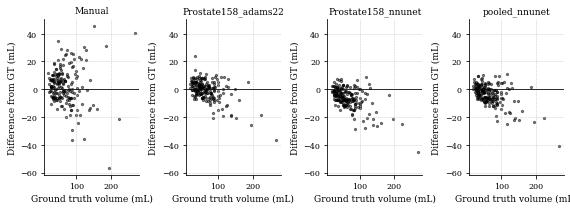

In [60]:
ncols = 4
nrows = -(-len(methods_with_manual) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(8, 3), sharex=True, sharey=True)
axes = axes.flatten()

for ax, method in zip(axes, methods_with_manual):
    diff = clinical[method] - clinical["gt"]
    ax.scatter(clinical["gt"], diff, s=5, alpha=0.5)
    ax.axhline(0, color="k", linewidth=0.8)
    ax.set_title({"prostate_volume": "Manual"}.get(method, method), fontsize=9)
    ax.set_xlabel("Ground truth volume (mL)")
    ax.set_ylabel("Difference from GT (mL)")

for ax in fig.axes:
    ax.tick_params(labelleft=True, labelbottom=True)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

for ax in axes[len(methods_with_manual):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


In [61]:
rows = {}
for method in methods_with_manual:
    diff = clinical[method] - clinical["gt"]
    m, s = diff.mean(), diff.std()
    desc = diff.describe()
    rows[{"prostate_volume": "Manual"}.get(method, method)] = {
        "mean": m,
        "95% LoA": f"[{m - 1.96*s:.1f}, {m + 1.96*s:.1f}]",
        "min": desc["min"], "25%": desc["25%"], "50%": desc["50%"],
        "75%": desc["75%"], "max": desc["max"], "N": int(desc["count"])
    }

df = pd.DataFrame(rows).T

numeric_cols = ["mean", "min", "25%", "50%", "75%", "max"]
df[numeric_cols] = df[numeric_cols].astype(float)

fmt = {c: "{:.1f}" for c in numeric_cols}
fmt["N"] = "{:.0f}"

df.style.format(fmt)

,mean,95% LoA,min,25%,50%,75%,max,N
Manual,2.4,"[-24.2, 29.1]",-56.5,-5.8,2.1,9.8,45.2,189
Prostate158_adams22,-0.6,"[-15.2, 14.1]",-36.9,-4.0,0.4,4.2,23.8,189
Prostate158_nnunet,-6.3,"[-21.2, 8.6]",-44.9,-9.5,-5.6,-1.5,9.0,189
pooled_nnunet,-3.7,"[-18.2, 10.9]",-41.1,-7.2,-2.7,1.1,11.0,189


In [62]:
icc_methods_clinical = ["gt"] + methods_with_manual
n = len(icc_methods_clinical)
icc_vals_clinical = pd.DataFrame(np.ones((n, n)), index=icc_methods_clinical, columns=icc_methods_clinical)

for m1, m2 in combinations(icc_methods_clinical, 2):
    long = pd.concat([
        clinical[["ID", m1]].rename(columns={m1: "volume"}).assign(rater=m1),
        clinical[["ID", m2]].rename(columns={m2: "volume"}).assign(rater=m2),
    ]).dropna(subset=["volume"])

    res = pg.intraclass_corr(data=long, targets="ID", raters="rater", ratings="volume", nan_policy='omit')
    row = res.set_index("Type").loc["ICC(A,1)"]
    icc = row["ICC"]

    icc_vals_clinical.loc[m1, m2] = icc
    icc_vals_clinical.loc[m2, m1] = icc

print("ICC(A,1) — two-way mixed, absolute agreement (volume, mL, matched subset)\n")
icc_vals_clinical.style.background_gradient(cmap="RdYlGn", vmin=0.8, vmax=1).format(precision=3)


ICC(A,1) — two-way mixed, absolute agreement (volume, mL, matched subset)



,gt,prostate_volume,Prostate158_adams22,Prostate158_nnunet,pooled_nnunet
gt,1.000,0.935,0.978,0.962,0.973
prostate_volume,0.935,1.000,0.933,0.912,0.924
Prostate158_adams22,0.978,0.933,1.000,0.980,0.991
Prostate158_nnunet,0.962,0.912,0.980,1.000,0.995
pooled_nnunet,0.973,0.924,0.991,0.995,1.000


### PSAD comparison, matched subset, restricted to clinically relevant range (GT PSAD < 0.3)

In [63]:
psad = clinical.copy()
for method in methods_with_manual:
    psad[method] = psad["psa"] / clinical[method]
psad["gt"] = psad["psa"] / clinical["gt"]

psad = psad[psad["gt"] < 0.3]  # restrict to clinically relevant range
print(f"{len(psad)} / {len(clinical)} matched cases have GT PSAD < 0.3.")
psad


139 / 189 matched cases have GT PSAD < 0.3.


,ID,t2,label_wg,Prostate158_adams22,Prostate158_nnunet,pooled_nnunet,gt,patient_id,study_id,mri_date,patient_age,psa,psad,prostate_volume,histopath_type,lesion_GS,lesion_ISUP,case_ISUP,case_csPCa,center
0,ProstateX-0000,/home/bshi/Documents/prostate_train/data/raw/g...,45.158250,0.271041,0.322679,0.304564,0.287877,11373.0,1001396.0,2012-01-04,63.0,13.00,0.25,0.250000,MRBx,4+3,3,3.0,YES,RUMC
1,ProstateX-0001,/home/bshi/Documents/prostate_train/data/raw/g...,33.600750,0.182345,0.200165,0.186623,0.151782,10795.0,1000811.0,2011-12-07,67.0,5.10,0.18,0.182143,MRBx,"3+3,0+0","1,0",1.0,NO,RUMC
2,ProstateX-0002,/home/bshi/Documents/prostate_train/data/raw/g...,28.818000,0.183933,0.201635,0.187767,0.211673,11149.0,1001172.0,2011-12-24,61.0,6.10,0.16,0.156410,MRBx,"3+4,3+3","2,1",2.0,YES,RUMC
3,ProstateX-0003,/home/bshi/Documents/prostate_train/data/raw/g...,136.920000,0.077927,0.081899,0.081187,0.075957,10310.0,1000316.0,2012-05-12,70.0,10.40,0.08,0.085246,NaN,NaN,NaN,0.0,NO,RUMC
4,ProstateX-0004,/home/bshi/Documents/prostate_train/data/raw/g...,160.324875,0.185714,0.207964,0.195574,0.176517,10787.0,1000803.0,2012-03-26,68.0,28.30,0.19,0.193836,MRBx,2+4,1,1.0,NO,RUMC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,ProstateX-0193,/home/bshi/Documents/prostate_train/data/raw/g...,36.255000,0.240708,0.278683,0.267512,0.275824,10019.0,1000019.0,2012-12-15,61.0,10.00,0.24,0.238095,MRBx,"N/A,N/A,N/A,3+4",2,2.0,YES,RUMC
194,ProstateX-0194,/home/bshi/Documents/prostate_train/data/raw/g...,91.693500,0.102276,0.110431,0.106409,0.112331,10418.0,1000426.0,2012-11-07,71.0,10.30,0.12,0.121176,MRBx,3+4,2,2.0,YES,RUMC
195,ProstateX-0195,/home/bshi/Documents/prostate_train/data/raw/g...,36.458250,0.234926,0.248203,0.237634,0.252343,10322.0,1000328.0,2012-11-03,73.0,9.20,0.28,0.287500,MRBx,4+4,4,4.0,YES,RUMC
196,ProstateX-0196,/home/bshi/Documents/prostate_train/data/raw/g...,49.260000,0.168637,0.184455,0.173127,0.164434,10688.0,1000704.0,2012-12-19,55.0,8.10,NaN,0.150000,MRBx,"5+4,4+3,4+5","5,3,5",5.0,YES,RUMC


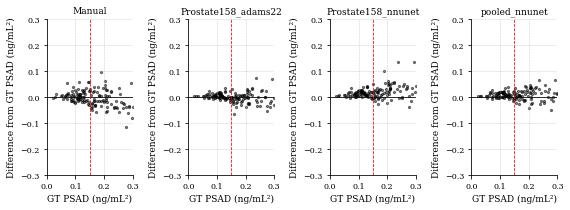

In [64]:
import matplotlib.ticker as ticker

ncols = 4
nrows = -(-len(methods_with_manual) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(8, 3), sharex=True, sharey=True)
axes = axes.flatten()

for ax, method in zip(axes, methods_with_manual):
    ax.scatter(psad["gt"], psad[method] - psad["gt"], s=5, alpha=0.5)
    ax.axhline(0, color="k", linewidth=0.8)
    ax.set_title({"prostate_volume": "Manual"}.get(method, method), fontsize=9)
    ax.set_xlabel("GT PSAD (ng/mL²)")
    ax.set_ylabel("Difference from GT PSAD (ng/mL²)")

for ax in fig.axes:
    ax.tick_params(labelleft=True, labelbottom=True)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    formatter = ticker.ScalarFormatter()
    formatter.set_powerlimits((-np.inf, np.inf))
    ax.xaxis.set_major_formatter(formatter)
    ax.set_xlim([0.0, 0.3])
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
    ax.set_ylim([-0.3, 0.3])
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
    ax.axvline(0.15, color="r", linewidth=0.8, linestyle="--")

for ax in axes[len(methods_with_manual):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


In [65]:
rows = {}
for method in methods_with_manual:
    diff = psad[method] - psad["gt"]
    m, s = diff.mean(), diff.std()
    desc = diff.describe()
    rows[{"prostate_volume": "Manual"}.get(method, method)] = {
        "mean": m,
        "95% LoA": f"[{m - 1.96*s:.1f}, {m + 1.96*s:.1f}]",
        "min": desc["min"], "25%": desc["25%"], "50%": desc["50%"],
        "75%": desc["75%"], "max": desc["max"], "N": int(desc["count"])
    }

df = pd.DataFrame(rows).T

numeric_cols = ["mean", "min", "25%", "50%", "75%", "max"]
df[numeric_cols] = df[numeric_cols].astype(float)

fmt = {c: "{:.3f}" for c in numeric_cols}
fmt["N"] = "{:.0f}"

df.style.format(fmt)

,mean,95% LoA,min,25%,50%,75%,max,N
Manual,-0.003,"[-0.1, 0.1]",-0.118,-0.020,-0.002,0.013,0.095,139
Prostate158_adams22,-0.000,"[-0.0, 0.0]",-0.067,-0.008,0.000,0.009,0.073,139
Prostate158_nnunet,0.019,"[-0.0, 0.1]",-0.038,0.004,0.015,0.028,0.136,139
pooled_nnunet,0.009,"[-0.0, 0.0]",-0.050,-0.001,0.008,0.019,0.067,139


In [66]:
icc_methods_psad = ["gt"] + methods_with_manual
n = len(icc_methods_psad)
icc_vals_psad = pd.DataFrame(np.ones((n, n)), index=icc_methods_psad, columns=icc_methods_psad)

for m1, m2 in combinations(icc_methods_psad, 2):
    long = pd.concat([
        psad[["ID", m1]].rename(columns={m1: "psad"}).assign(rater=m1),
        psad[["ID", m2]].rename(columns={m2: "psad"}).assign(rater=m2),
    ]).dropna(subset=["psad"])

    res = pg.intraclass_corr(data=long, targets="ID", raters="rater", ratings="psad", nan_policy='omit')
    row = res.set_index("Type").loc["ICC(A,1)"]
    icc = row["ICC"]

    icc_vals_psad.loc[m1, m2] = icc
    icc_vals_psad.loc[m2, m1] = icc

print("ICC(A,1) — two-way mixed, absolute agreement (PSAD, GT PSAD < 0.3)\n")
icc_vals_psad.style.background_gradient(cmap="RdYlGn", vmin=0.8, vmax=1).format(precision=3)


ICC(A,1) — two-way mixed, absolute agreement (PSAD, GT PSAD < 0.3)



,gt,prostate_volume,Prostate158_adams22,Prostate158_nnunet,pooled_nnunet
gt,1.000,0.883,0.956,0.910,0.953
prostate_volume,0.883,1.000,0.910,0.852,0.889
Prostate158_adams22,0.956,0.910,1.000,0.934,0.974
Prostate158_nnunet,0.910,0.852,0.934,1.000,0.975
pooled_nnunet,0.953,0.889,0.974,0.975,1.000



=== prostate_volume ===
Cohen's kappa (linear):    0.678
Cohen's kappa (quadratic): 0.703
              precision    recall  f1-score   support

       <0.10       0.92      0.83      0.87        29
     0.10–15       0.67      0.78      0.72        41
     0.15–20       0.53      0.55      0.54        31
     0.20–30       0.82      0.71      0.76        38

    accuracy                           0.72       139
   macro avg       0.73      0.72      0.72       139
weighted avg       0.73      0.72      0.72       139


=== Prostate158_adams22 ===
Cohen's kappa (linear):    0.823
Cohen's kappa (quadratic): 0.840
              precision    recall  f1-score   support

       <0.10       0.96      0.86      0.91        29
     0.10–15       0.76      0.95      0.85        41
     0.15–20       0.74      0.65      0.69        31
     0.20–30       0.94      0.87      0.90        38

    accuracy                           0.84       139
   macro avg       0.85      0.83      0.84       139

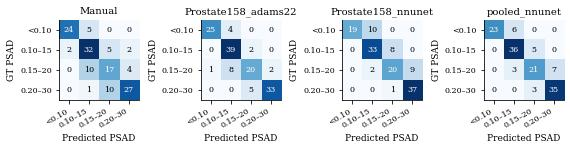

In [67]:
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score

cutoffs = [0.10, 0.15, 0.20]
bins = [0] + cutoffs + [np.inf]
bin_labels = ["<0.10", "0.10\u201315", "0.15\u201320", "0.20\u201330"]

gt_cat = pd.cut(psad["gt"], bins=bins, labels=bin_labels, right=False)

ncols = 4
nrows = -(-len(methods_with_manual) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(8, 3))
axes = axes.flatten()

for ax, method in zip(axes, methods_with_manual):
    pred_cat = pd.cut(psad[method], bins=bins, labels=bin_labels, right=False)

    valid = gt_cat.notna() & pred_cat.notna()
    cm = confusion_matrix(gt_cat[valid], pred_cat[valid], labels=bin_labels)

    kappa = cohen_kappa_score(gt_cat[valid], pred_cat[valid], weights="linear")
    kappa_quad = cohen_kappa_score(gt_cat[valid], pred_cat[valid], weights="quadratic")
    print(f"\n=== {method} ===")
    print(f"Cohen's kappa (linear):    {kappa:.3f}")
    print(f"Cohen's kappa (quadratic): {kappa_quad:.3f}")
    print(classification_report(gt_cat[valid], pred_cat[valid], labels=bin_labels, zero_division=0))

    ax.imshow(cm, cmap="Blues")
    for i in range(4):
        for j in range(4):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels(bin_labels, rotation=30, ha="right")
    ax.set_yticklabels(bin_labels)
    ax.set_xlabel("Predicted PSAD")
    ax.set_ylabel("GT PSAD")
    ax.set_title({"prostate_volume": "Manual"}.get(method, method))

for ax in axes[len(methods_with_manual):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()
